In [243]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix,accuracy_score,classification_report


In [244]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')

In [245]:
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [246]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [247]:
data.duplicated().sum()

np.int64(240)

In [248]:
data=data.drop_duplicates()

In [249]:
data.duplicated().sum()

np.int64(0)

In [250]:
data.info()

<class 'pandas.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 138.0 KB


In [251]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


C:\Users\myjyu\AppData\Local\Temp\ipykernel_6308\774239896.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data,x='quality',palette='copper')


Text(0.5, 1.0, 'Wine Quality')

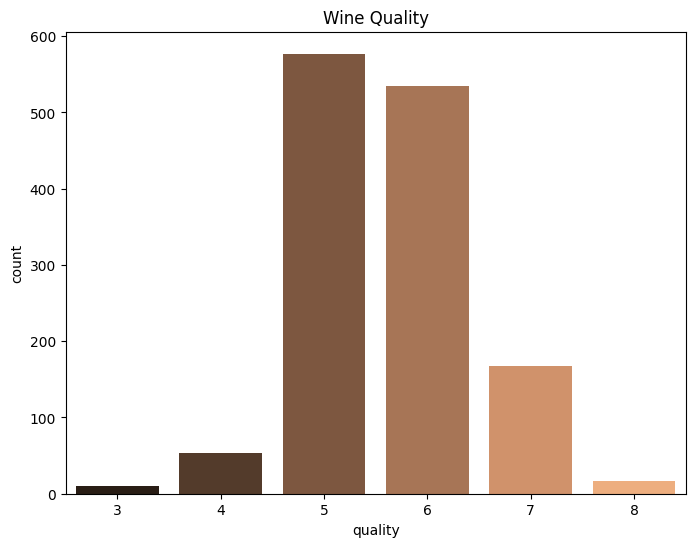

In [252]:
plt.figure(figsize=(8,6))
sns.countplot(data=data,x='quality',palette='copper')
plt.title("Wine Quality")

C:\Users\myjyu\AppData\Local\Temp\ipykernel_6308\3055709697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y='alcohol',x='quality',palette="RdBu")


Text(0.5, 1.0, 'Distribution of Alcohol Content Across Wine Quality ')

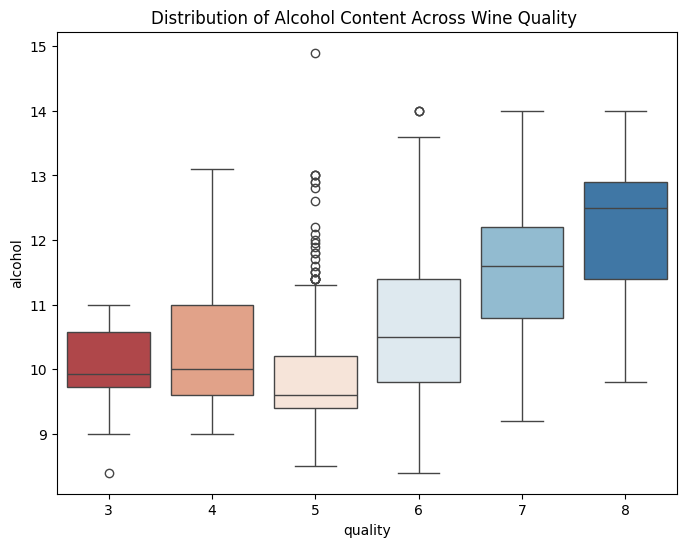

In [253]:
plt.figure(figsize=(8,6))
sns.boxplot(data=data,y='alcohol',x='quality',palette="RdBu")
plt.title("Distribution of Alcohol Content Across Wine Quality ")

C:\Users\myjyu\AppData\Local\Temp\ipykernel_6308\3947967471.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,x="quality",y="pH",palette="PRGn")


Text(0.5, 1.0, 'pH Level By Wine Quality ')

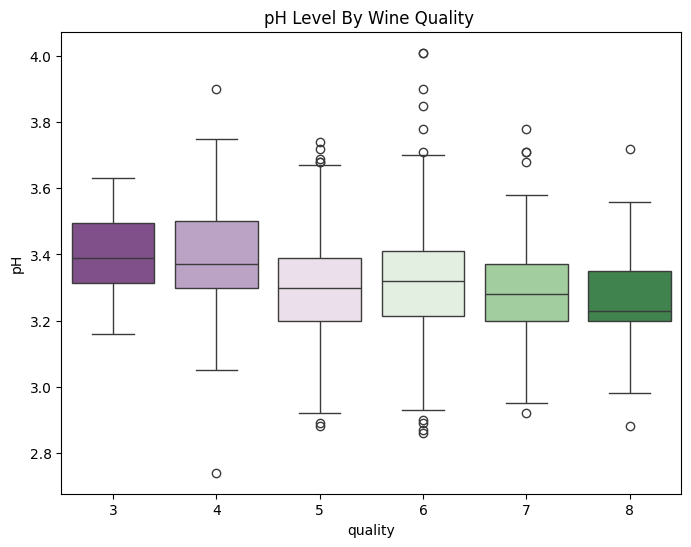

In [254]:
plt.figure(figsize=(8,6))
sns.boxplot(data=data,x="quality",y="pH",palette="PRGn")
plt.title("pH Level By Wine Quality ")

C:\Users\myjyu\AppData\Local\Temp\ipykernel_6308\718706433.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='quality', y='volatile acidity',


Text(0.5, 1.0, 'Volatile Acidity vs Wine Quality')

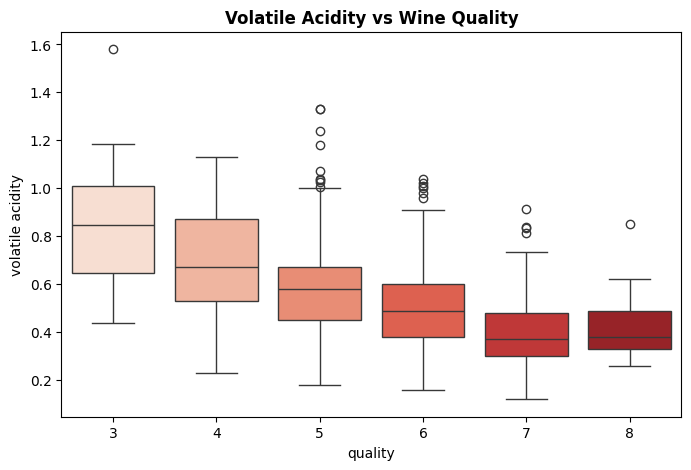

In [255]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='quality', y='volatile acidity',
            palette='Reds')
plt.title("Volatile Acidity vs Wine Quality", fontweight='bold')

In [256]:
x=data.drop("quality",axis=1)
y=data['quality']

In [257]:
x.shape

(1359, 11)

In [258]:
x_train_m,x_test_m,y_train_m,y_test_m=train_test_split(x,y,random_state=42)
scaler=StandardScaler()
x_train_m_s=scaler.fit_transform(x_train_m)
x_test_m_s=scaler.transform(x_test_m)

In [259]:
bestrange=range(1,31)
cv_score=[]
for i in bestrange:
    knn=KNeighborsClassifier(n_neighbors=i)
    score=cross_val_score(knn,x_train_m_s,y_train_m,cv=5,scoring='accuracy').mean()
    cv_score.append(score)
best_k_m = bestrange[np.argmax(cv_score)] 
print("Best n_neighbor=",best_k_m)  


Best n_neighbor= 11


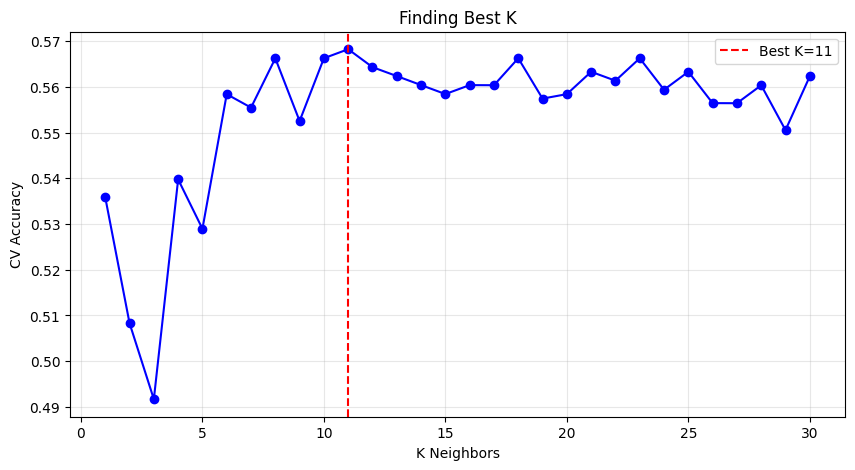

In [260]:
plt.figure(figsize=(10, 5))
plt.plot(bestrange,cv_score, marker='o', color='blue')
plt.axvline(best_k_m, color='red', linestyle='--',label=f'Best K={best_k_m}')
plt.title("Finding Best K")
plt.xlabel("K Neighbors")
plt.ylabel("CV Accuracy")
plt.legend()
plt.grid(alpha=0.3)


In [261]:
knn=KNeighborsClassifier(n_neighbors=best_k_m)
knn.fit(x_train_m_s,y_train_m)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [262]:
y_pred_m=knn.predict(x_test_m_s)
y_pred_m

array([5, 6, 7, 5, 6, 7, 5, 5, 6, 6, 7, 6, 6, 5, 6, 5, 5, 5, 5, 6, 5, 6,
       5, 5, 5, 5, 6, 5, 5, 6, 6, 7, 6, 5, 6, 6, 5, 6, 5, 6, 4, 6, 6, 5,
       5, 5, 5, 5, 5, 6, 5, 6, 5, 5, 7, 5, 6, 5, 5, 6, 5, 7, 5, 6, 6, 6,
       5, 5, 7, 7, 5, 7, 6, 6, 6, 5, 5, 5, 5, 5, 6, 6, 6, 5, 5, 6, 6, 5,
       6, 6, 6, 5, 5, 5, 6, 5, 5, 7, 6, 5, 5, 5, 5, 5, 4, 5, 6, 6, 7, 6,
       5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 5, 5, 5, 6, 6, 5, 5, 5, 5, 5, 5, 5,
       6, 6, 5, 5, 6, 6, 6, 5, 6, 5, 6, 7, 6, 6, 6, 6, 5, 5, 5, 6, 5, 5,
       5, 6, 5, 5, 7, 7, 5, 5, 5, 6, 6, 6, 5, 5, 6, 6, 7, 5, 6, 5, 7, 5,
       5, 5, 5, 6, 6, 6, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5, 7, 6, 5, 5, 7, 5,
       7, 6, 5, 6, 5, 7, 5, 6, 5, 5, 5, 6, 6, 6, 6, 5, 6, 5, 7, 7, 5, 6,
       5, 6, 5, 6, 5, 5, 6, 6, 5, 5, 6, 6, 7, 5, 6, 6, 6, 5, 5, 5, 5, 5,
       5, 5, 6, 5, 5, 6, 6, 7, 5, 5, 7, 6, 6, 6, 6, 5, 6, 6, 5, 5, 5, 5,
       6, 5, 6, 7, 5, 6, 6, 5, 7, 5, 5, 6, 5, 6, 6, 5, 5, 5, 6, 6, 6, 5,
       5, 5, 6, 6, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5, 5,

In [263]:
acc_m =accuracy_score(y_pred_m,y_test_m)
acc_m

0.6029411764705882

In [264]:
f1_m  =f1_score(y_test_m, y_pred_m, average='weighted')
f1_m  

0.5821611075926143

In [265]:
classification_report(y_pred_m,y_test_m)

c:\Users\myjyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\myjyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\myjyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

'              precision    recall  f1-score   support\n\n           3       0.00      0.00      0.00         0\n           4       0.00      0.00      0.00         2\n           5       0.76      0.65      0.70       175\n           6       0.57      0.55      0.56       136\n           7       0.41      0.63      0.50        27\n           8       0.00      0.00      0.00         0\n\n    accuracy                           0.60       340\n   macro avg       0.29      0.30      0.29       340\nweighted avg       0.65      0.60      0.62       340\n'

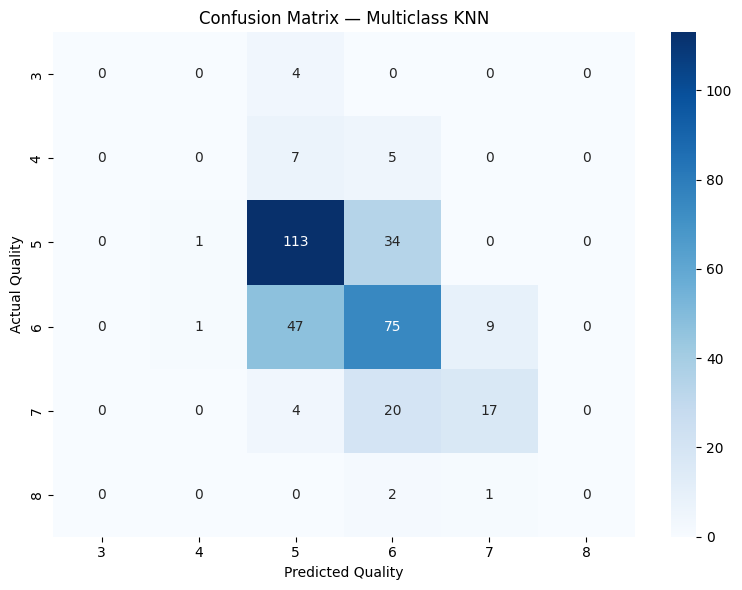

In [266]:
cm_m = confusion_matrix(y_test_m, y_pred_m)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues',xticklabels=sorted(y.unique()),yticklabels=sorted(y.unique()))
plt.title("Confusion Matrix — Multiclass KNN")
plt.ylabel("Actual Quality")
plt.xlabel("Predicted Quality")
plt.tight_layout()
plt.show()

Binary Approcy


In [267]:
data["binary_quality"]=(data["quality"]>=6).astype(int)


In [268]:
x=data.drop(["quality","binary_quality"],axis=1)
x.shape

(1359, 11)

In [269]:
y=data["binary_quality"]
y.shape

(1359,)

In [270]:
x_train_b,x_test_b,y_train_b,y_test_b=train_test_split(x,y,random_state=42)
scaler=StandardScaler()
x_train_b_s=scaler.fit_transform(x_train_b)
x_test_b_s=scaler.transform(x_test_b)

In [271]:
cv_s=[]
k_range=range(1,31)
for i in k_range:
    knn=KNeighborsClassifier(n_neighbors=i)
    score=cross_val_score(knn,x_train_b_s,y_train_b,cv=5,scoring='accuracy').mean()
    cv_s.append(score)
best_k_b = k_range[np.argmax(cv_s)]
best_k_b    

12

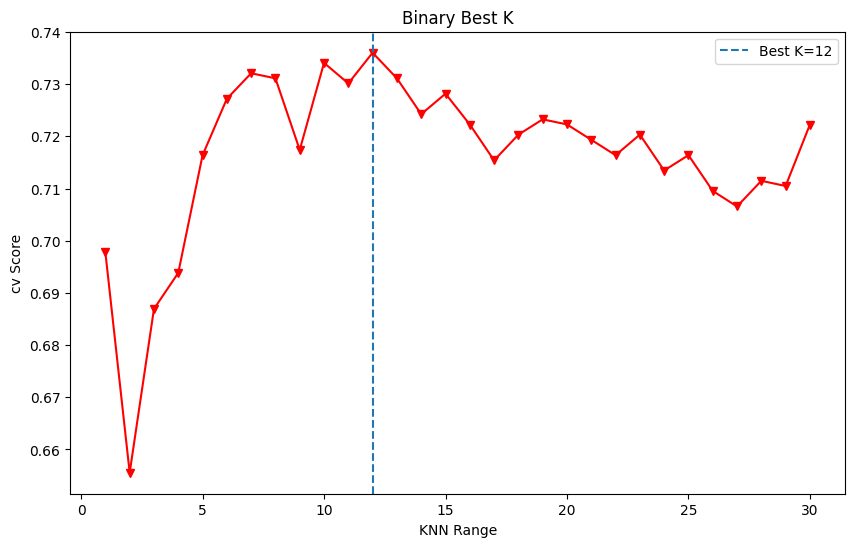

In [284]:
plt.figure(figsize=(10,6))
plt.plot(k_range,cv_s,marker="v",color='red')
plt.axvline(best_k_b,linestyle=('--'),label=f"Best K={best_k_b}")
plt.title("Binary Best K")
plt.xlabel("KNN Range")
plt.ylabel("cv Score")
plt.legend()

In [273]:
knn_b=KNeighborsClassifier(n_neighbors=best_k_b)
knn_b.fit(x_train_b_s,y_train_b)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",12
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [274]:
y_pred_b=knn_b.predict(x_test_b_s)
y_pred_b

array([0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,

In [275]:
acc_b=accuracy_score(y_pred_b,y_test_b)
acc_b

0.7382352941176471

In [276]:
f1_b=f1_score(y_pred_b,y_test_b)
f1_b

0.7359050445103857

In [277]:
classification_report(y_pred_b,y_test_b)

'              precision    recall  f1-score   support\n\n           0       0.77      0.71      0.74       179\n           1       0.70      0.77      0.74       161\n\n    accuracy                           0.74       340\n   macro avg       0.74      0.74      0.74       340\nweighted avg       0.74      0.74      0.74       340\n'

Text(0.5, 1.0, 'Confusion Matrix — Binary KNN')

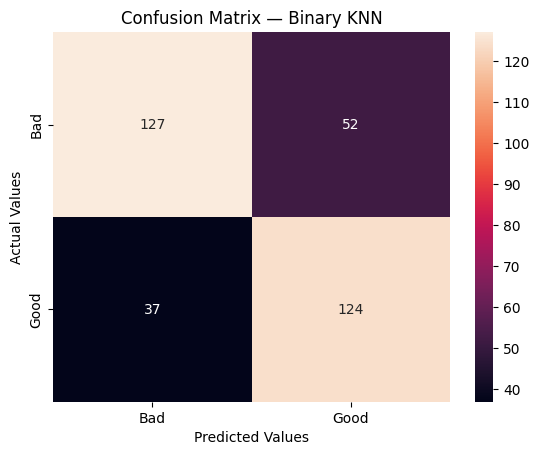

In [278]:
cm=confusion_matrix(y_pred_b,y_test_b)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['Bad','Good'],yticklabels=['Bad','Good'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix — Binary KNN")

In [279]:
comparison = pd.DataFrame({
    'Approach' : ['Multiclass (3-8)', 'Binary (Good/Bad)'],
    'Best K'   : [best_k_m, best_k_b],
    'Accuracy' : [round(acc_m, 4), round(acc_b, 4)],
    'F1 Score' : [round(f1_m, 4),  round(f1_b, 4)]
})
print(comparison)

            Approach  Best K  Accuracy  F1 Score
0   Multiclass (3-8)      11    0.6029    0.5822
1  Binary (Good/Bad)      12    0.7382    0.7359
